<a href="https://colab.research.google.com/github/tcs-codes/Market-Regime-Detection/blob/main/QC_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install hmmlearn

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
data = yf.download("^IXIC", start="2025-11-20", end="2026-01-12", interval="5m")

# FIX: Flatten MultiIndex columns correctly
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.columns)  # used this while debugging something

/tmp/ipython-input-1628233861.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^IXIC", start="2025-11-20", end="2026-01-12", interval="5m")
[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [ ]:
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

data = data[data['Volume'] > 0]

data['Amihud'] = np.abs(data['Returns']) / data['Volume']

data['SignedVolume'] = data['Volume'] * np.sign(data['Returns'])

data['Price_Impact'] = data['Returns'] / np.sqrt(data['Volume'])

avg_volume = data['Volume'].rolling(window=10).mean()
data['Order_Flow_Imbalance'] = data['SignedVolume'] / avg_volume

returns_vol = data['Returns'].rolling(window=5).std()
data['Volume_Scaled_Vol'] = returns_vol * np.sqrt(data['Volume'])

data['Price_Efficiency'] = np.abs(data['Returns']) * data['Volume']

data['Open'] = data['Open'].ffill()
data['Microstructure_Noise'] = (data['High'] - data['Low']) / np.abs(data['Close'] - data['Open'])

data['Volume_Acceleration'] = data['Volume'].diff().diff()

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)

In [ ]:
train_features = train_data[['Amihud', 'SignedVolume', 'Price_Impact', 'Order_Flow_Imbalance',
                 'Volume_Scaled_Vol', 'Price_Efficiency']].values

test_features = test_data[['Amihud', 'SignedVolume', 'Price_Impact', 'Order_Flow_Imbalance',
                 'Volume_Scaled_Vol', 'Price_Efficiency']].values

In [ ]:
# 3. Preprocessing (Scaling is mandatory!)
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_features)
test_X_scaled = scaler.transform(test_features)

In [ ]:
import numpy as np

# 1. Enhanced Microstructure Noise (with epsilon to avoid division issues)
epsilon = 1e-10
denominator = data['Returns']**2 * data['Volume']
denominator = denominator.replace(0, epsilon)  # Replace zeros
data['Enhanced_Noise'] = (data['High'] - data['Low'])**2 / denominator

# 2. Roll's Effective Spread
data['Returns_lag1'] = data['Returns'].shift(1)
cov_term = data['Returns'].rolling(20, min_periods=5).cov(data['Returns_lag1'])
data['Roll_Spread'] = 2 * np.sqrt(np.maximum(-cov_term, epsilon))

# 3. Realized Skewness (30-period)
data['Realized_Skewness'] = data['Returns'].rolling(30, min_periods=10).skew()

# 4. Realized Kurtosis (30-period)
data['Realized_Kurtosis'] = data['Returns'].rolling(30, min_periods=10).kurt()

# 5. Volume Clustering (Hurst Exponent of volume)
def hurst_exponent(ts):
    if len(ts) < 20:
        return np.nan
    ts = np.array(ts)
    lags = range(2, min(20, len(ts)//2))
    if len(lags) < 2:
        return np.nan

    tau = []
    for lag in lags:
        if len(ts) > lag:
            std_val = np.std(ts[lag:] - ts[:-lag])
            if std_val > 0:
                tau.append(std_val)

    if len(tau) < 2:
        return np.nan

    poly = np.polyfit(np.log(lags[:len(tau)]), np.log(tau), 1)
    return poly[0] * 2.0

data['Volume_Hurst'] = data['Volume'].rolling(100, min_periods=50).apply(hurst_exponent)

# 6. Order Flow Persistence
def ofi_persistence(x):
    x = np.array(x)
    if len(x) < 3:
        return np.nan
    try:
        corr_matrix = np.corrcoef(x[:-1], x[1:])
        return corr_matrix[0, 1] if not np.isnan(corr_matrix[0, 1]) else 0
    except:
        return 0

data['OFI_Persistence'] = data['Order_Flow_Imbalance'].rolling(10, min_periods=3).apply(ofi_persistence)

# Clean infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Forward fill rolling calculations
for col in ['Realized_Skewness', 'Realized_Kurtosis', 'Volume_Hurst', 'OFI_Persistence']:
    data[col] = data[col].ffill().bfill()

# Drop remaining NaNs
data.dropna(inplace=True)

In [ ]:
# Add robust scaling or clipping for extreme values
from sklearn.preprocessing import RobustScaler

# Replace outliers
for col in data.columns:
    if data[col].dtype in ['float64', 'float32']:
        q1 = data[col].quantile(0.01)
        q3 = data[col].quantile(0.99)
        data[col] = np.clip(data[col], q1, q3)

In [ ]:
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)

In [ ]:
train_features2 = train_data[['Enhanced_Noise', 'Roll_Spread', 'Realized_Skewness',
                  'Realized_Kurtosis', 'Volume_Hurst', 'OFI_Persistence']].values

test_features2 = test_data[['Enhanced_Noise', 'Roll_Spread', 'Realized_Skewness',
                  'Realized_Kurtosis', 'Volume_Hurst', 'OFI_Persistence']].values

In [ ]:
# 3. Preprocessing (Scaling is mandatory!)
scaler = StandardScaler()
train_X_scaled2 = scaler.fit_transform(train_features2)
test_X_scaled2 = scaler.transform(test_features2)

In [ ]:
# # 4. Train the HMM
# # We assume 3 regimes: Bearish/Volatile, Bullish/Stable, and Quiet/Sideways
# model = hmm.GaussianHMM(n_components=4, covariance_type="full", n_iter=100)
# model.fit(train_X_scaled2)

In [ ]:
model = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=1000,
    tol=1e-6,
    random_state=42
)

model.fit(train_X_scaled2)

GaussianHMM(covariance_type='full', n_components=4, n_iter=1000,
            random_state=42, tol=1e-06)

In [ ]:
# 5. Predict the current regime
test_data['Regime'] = model.predict(test_X_scaled2)

In [ ]:
# Check the characteristics of each regime
state_means = pd.DataFrame(scaler.inverse_transform(model.means_),
                           columns=['Enhanced_Noise', 'Roll_Spread', 'Realized_Skewness',
                  'Realized_Kurtosis', 'Volume_Hurst', 'OFI_Persistence'])
print(state_means)

   Enhanced_Noise  Roll_Spread  Realized_Skewness  Realized_Kurtosis  \
0       62.647745     0.000717          -1.030954           4.226780   
1       66.726361     0.000251           0.074814           0.323774   
2    19753.725973     0.000354           0.176548           1.918520   
3       50.670220     0.000574           2.127031           8.952531   

   Volume_Hurst  OFI_Persistence  
0      0.537893        -0.155317  
1      0.821137        -0.071137  
2      0.739714        -0.127753  
3      0.667371        -0.106895  


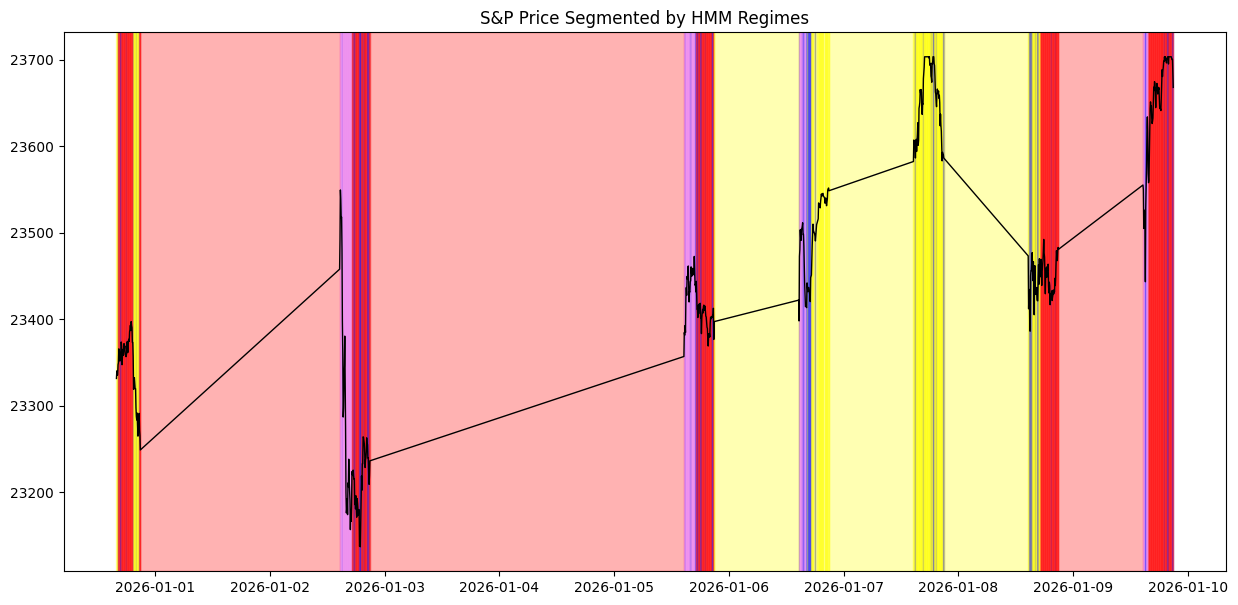

In [ ]:
plt.figure(figsize=(15, 7))
colors = ['yellow', 'red', 'blue', 'violet', 'black']

for i in range(len(test_data)):
    plt.axvspan(test_data.index[i], test_data.index[i+1] if i+1 < len(test_data) else test_data.index[i],
                color=colors[test_data['Regime'].iloc[i]], alpha=0.3)

plt.plot(test_data['Close'], color='black', lw=1)
plt.title("S&P Price Segmented by HMM Regimes")
plt.show()

In [ ]:
import numpy as np

# Assuming transmat is your transition matrix
np.set_printoptions(precision=4, suppress=True)
print("Transition Matrix:")
print(model.transmat_)
print()

# With row and column labels
print("    From State →")
print("To↓", end="")
for j in range(model.transmat_.shape[1]):
    print(f"   S{j}", end="")
print()
for i in range(model.transmat_.shape[0]):
    print(f"S{i}  ", end="")
    for j in range(model.transmat_.shape[1]):
        print(f"{model.transmat_[i,j]:.4f} ", end="")
    print()

Transition Matrix:
[[0.8882 0.0182 0.0936 0.    ]
 [0.011  0.8592 0.1179 0.0119]
 [0.1615 0.5978 0.1108 0.1299]
 [0.0064 0.0359 0.0759 0.8819]]

    From State →
To↓   S0   S1   S2   S3
S0  0.8882 0.0182 0.0936 0.0000 
S1  0.0110 0.8592 0.1179 0.0119 
S2  0.1615 0.5978 0.1108 0.1299 
S3  0.0064 0.0359 0.0759 0.8819 


In [ ]:
def calculate_regime_persistence(regime_labels):
    """Calculate how persistent regimes are"""
    changes = np.diff(regime_labels)
    persistence = 1 - (np.count_nonzero(changes) / len(changes))
    avg_duration = len(regime_labels) / (np.count_nonzero(changes) + 1)
    return persistence, avg_duration

calculate_regime_persistence(test_data['Regime'])

(0.7855711422845691, 4.62962962962963)

In [ ]:
# Calculate average returns per regime
for regime in [0, 1, 2, 3]:
    mask = test_data['Regime'] == regime
    avg_return = test_data.loc[mask, 'Returns'].mean()
    volatility = test_data.loc[mask, 'Returns'].std()
    print(f"Regime {regime}: μ={avg_return:.6f}, σ={volatility:.6f}")

Regime 0: μ=0.000008, σ=0.000782
Regime 1: μ=0.000024, σ=0.000548
Regime 2: μ=-0.000088, σ=0.000383
Regime 3: μ=0.000086, σ=0.001372


In [ ]:
def analyze_regime_features(data):
    for regime in [0, 1, 2, 3]:
        mask = test_data['Regime'] == regime
        regime_data = test_data[mask]

        print(f"\n--- Regime {regime} ---")
        print(f"Count: {len(regime_data)} periods")
        print(f"Avg Volume: {regime_data['Volume'].mean():.0f}")
        print(f"Avg Amihud: {regime_data['Amihud'].mean():.6f}")
        print(f"Avg Volatility: {regime_data['Returns'].std():.6f}")
        print(f"Avg Noise: {regime_data['Enhanced_Noise'].mean():.6f}")

analyze_regime_features(test_data)


--- Regime 0 ---
Count: 141 periods
Avg Volume: 488172028
Avg Amihud: 0.000000
Avg Volatility: 0.000782
Avg Noise: 59.159264

--- Regime 1 ---
Count: 221 periods
Avg Volume: 56157181
Avg Amihud: 0.000000
Avg Volatility: 0.000548
Avg Noise: 69.048381

--- Regime 2 ---
Count: 60 periods
Avg Volume: 309483352
Avg Amihud: 0.000000
Avg Volatility: 0.000383
Avg Noise: 28809.649602

--- Regime 3 ---
Count: 78 periods
Avg Volume: 168782841
Avg Amihud: 0.000000
Avg Volatility: 0.001372
Avg Noise: 48.128399
